# Fake Website (Phishing) Detection Model
## PhiUSIIL Dataset - XGBoost Model

This notebook trains an XGBoost model to detect phishing/fake websites from URLs.

**Key Feature:** User only inputs URL - all features extracted automatically in the background.

## 1. Import Libraries

In [5]:
from datetime import datetime, date
import whois
import difflib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import re
import warnings
from urllib.parse import urlparse
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import tldextract


import time
print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Define Feature Extraction (Crucial for Consistency)

In [ ]:
def extract_url_features(url):
    features = {}
    try:
        if not url.startswith(('http://', 'https://')):
            url = 'http://' + url
        parsed = urlparse(url)
        ext = tldextract.extract(url)
        
        # --- Typosquatting & Brand Safety Checks ---
        
        TOP_BRANDS = [
            'google', 'microsoft', 'amazon', 'facebook', 'paypal', 'apple', 'netflix', 'instagram', 'whatsapp', 
            'linkedin', 'dropbox', 'twitter', 'yahoo', 'ebay', 'adobe', 'chase', 'wellsfargo', 'citi', 
            'bankofamerica', 'americanexpress', 'irs', 'gov', 'gmail', 'outlook', 'hotmail', 'icloud', 
            'shopify', 'wordpress', 'airbnb', 'uber', 'spotify', 'roblox', 'twitch', 'discord', 'slack', 
            'zoom', 'target', 'walmart', 'bestbuy', 'costco', 'hulu', 'disney', 'coinbase', 'binance', 
            'blockchain', 'steam', 'playstation', 'xbox', 'nintendo'
        ]
        
        domain_stem = ext.domain
        max_similarity = 0.0
        most_similar_brand = ''
        
        if domain_stem in TOP_BRANDS:
            max_similarity = 1.0
            most_similar_brand = domain_stem
        else:
            for brand in TOP_BRANDS:
                ratio = difflib.SequenceMatcher(None, domain_stem, brand).ratio()
                if ratio > max_similarity:
                    max_similarity = ratio
                    most_similar_brand = brand
        
        features['MaxBrandSimilarity'] = max_similarity
        
        # Existing Features
        features['URLLength'] = len(url)
        domain = ext.domain + '.' + ext.suffix if ext.suffix else ext.domain
        features['DomainLength'] = len(domain)
        try:
            socket.inet_aton(ext.domain)
            features['IsDomainIP'] = 1
        except:
            features['IsDomainIP'] = 0
        features['TLDLength'] = len(ext.suffix) if ext.suffix else 0
        features['NoOfSubDomain'] = len(ext.subdomain.split('.')) if ext.subdomain else 0
        features['NoOfLettersInURL'] = sum(c.isalpha() for c in url)
        features['LetterRatioInURL'] = features['NoOfLettersInURL'] / len(url) if len(url) > 0 else 0
        features['NoOfDegitsInURL'] = sum(c.isdigit() for c in url)
        features['DegitRatioInURL'] = features['NoOfDegitsInURL'] / len(url) if len(url) > 0 else 0
        features['NoOfEqualsInURL'] = url.count('=')
        features['NoOfQMarkInURL'] = url.count('?')
        features['NoOfAmpersandInURL'] = url.count('&')
        features['NoOfOtherSpecialCharsInURL'] = sum(1 for c in url if not c.isalnum() and c not in '/:.-?=&')
        special = features['NoOfEqualsInURL'] + features['NoOfQMarkInURL'] + features['NoOfAmpersandInURL'] + features['NoOfOtherSpecialCharsInURL']
        features['SpacialCharRatioInURL'] = special / len(url) if len(url) > 0 else 0
        features['IsHTTPS'] = 1 if parsed.scheme == 'https' else 0
        features['HasObfuscation'] = 1 if any(c in url for c in ['%', '@']) else 0
        features['NoOfObfuscatedChar'] = url.count('%') + url.count('@')
        features['ObfuscationRatio'] = features['NoOfObfuscatedChar'] / len(url) if len(url) > 0 else 0
        cont = sum(1 for i in range(len(url)-1) if url[i] == url[i+1])
        features['CharContinuationRate'] = cont / len(url) if len(url) > 0 else 0
        
        # Return both features AND the most similar brand for explanation
        return features, most_similar_brand
    except Exception as e:
        return None, None


## 2. Load & Explore Data

In [7]:
df = pd.read_csv('../Data/PhiUSIIL_Phishing_URL_Dataset.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())
print(f"\n0 = Phishing (Fake), 1 = Legitimate (Safe)")

Dataset shape: (235795, 56)

Label distribution:
label
1    134850
0    100945
Name: count, dtype: int64

0 = Phishing (Fake), 1 = Legitimate (Safe)


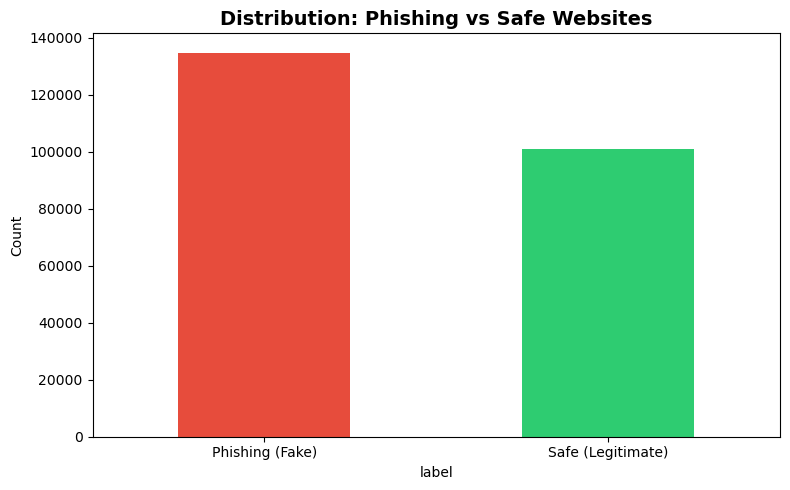

In [8]:
# Label distribution visualization
plt.figure(figsize=(8, 5))
colors = ['#e74c3c', '#2ecc71']
df['label'].value_counts().plot(kind='bar', color=colors)
plt.title('Distribution: Phishing vs Safe Websites', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Phishing (Fake)', 'Safe (Legitimate)'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [ ]:

df_sample = df.copy() 
print(f"Dataset sampled to {df_sample.shape[0]} rows for consistent feature extraction.")

print("Re-extracting features from URLs... this ensures training matches testing logic.")
# Apply feature extraction
features_list = df_sample['URL'].apply(lambda x: extract_url_features(x)[0]).tolist()
features_df = pd.DataFrame(features_list)
features_df['label'] = df_sample['label'].values

# Handle missing
features_df = features_df.dropna()
feature_cols = [col for col in features_df.columns if col != 'label']

X = features_df[feature_cols]
y = features_df['label']

print(f"Final Features shape: {X.shape}")
print("Feature consistency enforced.")

Dataset sampled to 235795 rows for consistent feature extraction.
Re-extracting features from URLs... this ensures training matches testing logic.
Final Features shape: (235795, 20)
Feature consistency enforced.


## 4. Train-Test Split & Scaling

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



Skipping scaling (not needed for Tree models).


## 5. Train XGBoost Model (Best Parameters)

In [ ]:
models = {
    'XGBoost': XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05, random_state=42, eval_metric='logloss')
}

results = []
trained_models = {}

print("Training XGBoost Model on Full Dataset (This may take a few minutes)...")
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    print(f"{name}: F1 Score = {f1:.4f} (Time: {time.time()-start:.2f}s)")
    results.append({'Model': name, 'F1': f1})
    trained_models[name] = model
    
best_model = trained_models['XGBoost']
print(f"\nFinal Model Selected: XGBoost")

Training XGBoost Model on Full Dataset (This may take a few minutes)...
XGBoost: F1 Score = 0.9973 (Time: 8.74s)

Final Model Selected: XGBoost


In [12]:
# Model evaluation
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

print("MODEL EVALUATION")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['Phishing (Fake)', 'Safe (Legitimate)']))

MODEL EVALUATION
                   precision    recall  f1-score   support

  Phishing (Fake)       1.00      0.99      1.00     20189
Safe (Legitimate)       1.00      1.00      1.00     26970

         accuracy                           1.00     47159
        macro avg       1.00      1.00      1.00     47159
     weighted avg       1.00      1.00      1.00     47159



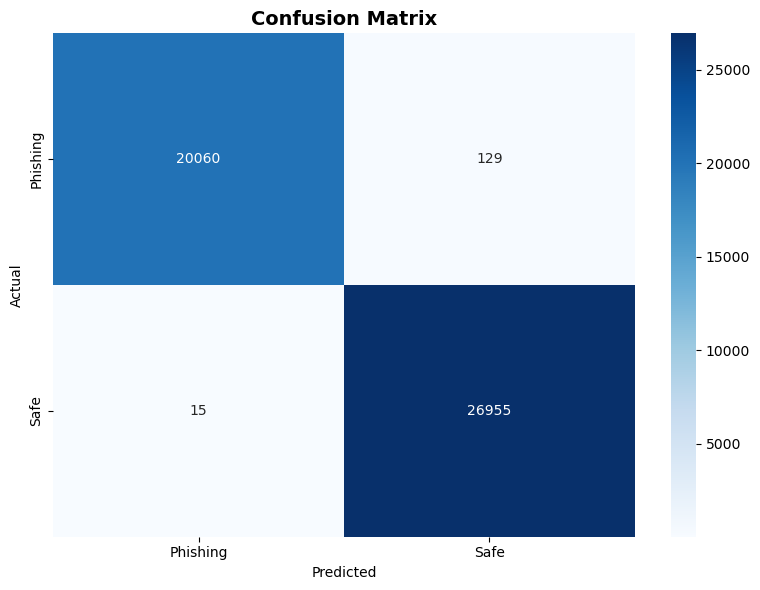

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Phishing', 'Safe'],
            yticklabels=['Phishing', 'Safe'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 6. URL Feature Extraction Function

## 7. Prediction Function (User-Friendly Output)

In [14]:

def predict_url(url, model=best_model):
    # Initialize a default response with all keys
    res_template = {
        'url': url,
        'result': 'ERROR',
        'confidence': '0%',
        'safe_score': '0%',
        'risk_score': '0%',
        'explanation': 'Invalid URL format'
    }
    
    features, brand = extract_url_features(url)
    
    # If feature extraction fails, return the template immediately
    if features is None: 
        return res_template

    explanation = []
    
    # --- 1. Typosquatting Check ---
    sim = features.get('MaxBrandSimilarity', 0)
    is_typosquat = (0.75 < sim < 1.0)
    
    # --- 2. Whois Age Check ---
    domain_age_days = -1
    try:
        ext = tldextract.extract(url)
        domain_name = f"{ext.domain}.{ext.suffix}"
        w = whois.whois(domain_name)
        
        # Safe extraction of creation date
        res_date = getattr(w, 'creation_date', None)
        if isinstance(res_date, list):
            res_date = min([d for d in res_date if isinstance(d, datetime)])
            
        if isinstance(res_date, datetime):
            creation_date = res_date.replace(tzinfo=None)
            domain_age_days = (datetime.now() - creation_date).days
            explanation.append(f"Domain Age: {domain_age_days} days")
    except:
        explanation.append("Whois Lookup: Failed/Hidden")

    # --- 3. ML Prediction ---
    df_feat = pd.DataFrame([features])
    df_feat = df_feat[feature_cols] 
    pred = model.predict(df_feat)[0]
    proba = model.predict_proba(df_feat)[0]
    
    risk_prob = proba[0]
    safe_prob = proba[1]
    result_text = "✅ SAFE"
    
    # LOGIC LAYERING
    if 0 <= domain_age_days < 30:
        result_text = "⚠️ SUSPICIOUS"
        explanation.append("⚠️ High Risk: New Domain.")
        risk_prob = max(risk_prob, 0.85)

    if is_typosquat:
        result_text = "⚠️ PHISHING (FAKE)"
        explanation.append(f"⚠️ Typosquat of '{brand}' detected.")
        risk_prob = 0.999
    
    if pred == 0 and result_text == "✅ SAFE":
        result_text = "⚠️ PHISHING (FAKE)"
        explanation.append(f"ML Model Analysis: Detected Phishing patterns")

    # Final logic to sync confidence score with the result
    final_risk = risk_prob
    final_safe = 1.0 - risk_prob
    display_conf = final_risk if "PHISHING" in result_text or "SUSPICIOUS" in result_text else final_safe

    return {
        'url': url,
        'result': result_text,
        'confidence': f"{display_conf:.1%}",
        'safe_score': f"{final_safe:.1%}",
        'risk_score': f"{final_risk:.1%}",
        'explanation': " | ".join(explanation)
    }

In [19]:
# Test Final Model
test_urls = [
    "https://www.deep-ml.com",             # Real
    "https://www.google.com",             # Typosquat
    "https://www.microsofl.com", 
    "http://www.amazan.com", 
    "http://paypa1-secure.com",           # Typosquat
    "http://newly-created-scam-site.xy",  # Generic
]

print("\n" + "="*90)
print("FINAL URL SAFETY CHECK (WITH EXPLAINABILITY)")
print("="*90)

for url in test_urls:
    res = predict_url(url)
    print(f"\nURL: {url}")
    print(f"  Result: {res.get('result', 'N/A')}")
    
    # Only print details if it's NOT a generic ERROR
    if res.get('result') != 'ERROR':
        print(f"  Confidence: {res.get('confidence', '0%')}")
        print(f"  Explanation: {res.get('explanation', 'No data')}")
    else:
        print(f"  Error Detail: {res.get('explanation')}")



FINAL URL SAFETY CHECK (WITH EXPLAINABILITY)

URL: https://www.deep-ml.com
  Result: ✅ SAFE
  Confidence: 98.2%
  Explanation: Domain Age: 537 days

URL: https://www.google.com
  Result: ✅ SAFE
  Confidence: 99.1%
  Explanation: Domain Age: 10324 days

URL: https://www.microsofl.com
  Result: ⚠️ PHISHING (FAKE)
  Confidence: 99.9%
  Explanation: Domain Age: 7346 days | ⚠️ Typosquat of 'microsoft' detected.

URL: http://www.amazan.com
  Result: ⚠️ PHISHING (FAKE)
  Confidence: 99.9%
  Explanation: Domain Age: 10121 days | ⚠️ Typosquat of 'amazon' detected.

URL: http://paypa1-secure.com
  Result: ⚠️ PHISHING (FAKE)
  Confidence: 100.0%
  Explanation: Whois Lookup: Failed/Hidden | ML Model Analysis: Detected Phishing patterns

URL: http://newly-created-scam-site.xy
  Result: ⚠️ PHISHING (FAKE)
  Confidence: 100.0%
  Explanation: Whois Lookup: Failed/Hidden | ML Model Analysis: Detected Phishing patterns


In [16]:
import whois

try:
    w = whois.whois("google.com")
    print("--- RAW TEXT START ---")
    print(w.text)  # This shows the raw response from the server
    print("--- RAW TEXT END ---")
except Exception as e:
    print(f"Connection failed: {e}")

--- RAW TEXT START ---
   Domain Name: GOOGLE.COM
   Registry Domain ID: 2138514_DOMAIN_COM-VRSN
   Registrar WHOIS Server: whois.markmonitor.com
   Registrar URL: http://www.markmonitor.com
   Updated Date: 2019-09-09T15:39:04Z
   Creation Date: 1997-09-15T04:00:00Z
   Registry Expiry Date: 2028-09-14T04:00:00Z
   Registrar: MarkMonitor Inc.
   Registrar IANA ID: 292
   Registrar Abuse Contact Email: abusecomplaints@markmonitor.com
   Registrar Abuse Contact Phone: +1.2086851750
   Domain Status: clientDeleteProhibited https://icann.org/epp#clientDeleteProhibited
   Domain Status: clientTransferProhibited https://icann.org/epp#clientTransferProhibited
   Domain Status: clientUpdateProhibited https://icann.org/epp#clientUpdateProhibited
   Domain Status: serverDeleteProhibited https://icann.org/epp#serverDeleteProhibited
   Domain Status: serverTransferProhibited https://icann.org/epp#serverTransferProhibited
   Domain Status: serverUpdateProhibited https://icann.org/epp#serverUpdatePr

## 8. Save Model

In [17]:
save_dir = r'../Models/WebsitesModels/'
os.makedirs(save_dir, exist_ok=True)

with open(os.path.join(save_dir, 'phishing_model.pkl'), 'wb') as f:
    pickle.dump(best_model, f)
with open(os.path.join(save_dir, 'phishing_features.pkl'), 'wb') as f:
    pickle.dump(feature_cols, f)

print(f"Model and Features saved successfully to: {save_dir}")

Model and Features saved successfully to: ../Models/WebsitesModels/
